# Fase 3 — Acoplamiento balancin-sarta (cinematica impuesta)

Se impone el movimiento del balancin como **BC superior** de la ecuacion de onda, con velocidad angular $\omega$ constante.

La bomba se modela como carga ideal alternante:
- **Upstroke** ($\dot u_{embolo} > 0$): $F_{pump} = (P_d - P_s)\, A_p$
- **Downstroke** ($\dot u_{embolo} \leq 0$): $F_{pump} = 0$

La carta dinamometrica de superficie ($F_{PR}$ vs $y_{PR}$) es la salida principal.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator.params import *
from aib_simulator.geometry import polished_rod_position, full_kinematics
from aib_simulator.rod_string import WaveSolver
from aib_simulator.pump import PumpModel

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Geometria del mecanismo
A, C, I, H, P, R = A_beam, C_beam, I_geom, H_geom, P_pitman, R_crank

# Presiones de la bomba (modelo cuasi-estatico)
P_d = P_wh + rho_f * g * L_bomba
P_s = P_ann + rho_f * g * (L_bomba - h_din_0)
F_fluid_load = (P_d - P_s) * pump_A

print(f"Presion descarga P_d = {P_d/1e6:.3f} MPa")
print(f"Presion succion  P_s = {P_s/1e6:.3f} MPa")
print(f"Carga de fluido F_fluid = {F_fluid_load/1e3:.1f} kN")
print(f"Peso flotado sarta W_rod_fl = {W_rod_fl/1e3:.1f} kN")
print(f"PPRL estatico = W_fl + F_fluid = {(W_rod_fl + F_fluid_load)/1e3:.1f} kN")

Presion descarga P_d = 11.377 MPa
Presion succion  P_s = 3.167 MPa
Carga de fluido F_fluid = 12.7 kN
Peso flotado sarta W_rod_fl = 22.5 kN
PPRL estatico = W_fl + F_fluid = 35.3 kN


## Simulacion a omega constante (6 SPM)

Se pre-computa la cinematica del balancin y se usa como BC superior para la PDE de la sarta. La simulacion corre varios ciclos hasta alcanzar regimen periodico.

In [2]:
# Pre-computar cinematica del balancin
SPM = SPM_base  # 6 SPM
omega_crank = 2 * np.pi * SPM / 60
T_cycle = 60.0 / SPM
n_steps_cycle = int(T_cycle / dt)

theta_table = np.linspace(0, 2 * np.pi, 3600)
kin = full_kinematics(theta_table, omega_crank, A, C, I, H, P, R)
y_PR_table = kin['y_PR']
y_PR_eq = (np.max(y_PR_table) + np.min(y_PR_table)) / 2

def y_PR_interp(theta_val):
    return np.interp(theta_val % (2 * np.pi), theta_table, y_PR_table)

# Gravedad efectiva
g_eff = g * (1 - rho_f / rod_rho)
w_fl = rod_w * (1 - rho_f / rod_rho)

# Solver con gravedad
solver = WaveSolver(N=N_nodes, L=rod_L, E=rod_E, rho=rod_rho, A_r=rod_A,
                    c_damp=rod_c, dt=dt, g_eff=g_eff)
x = solver.x
u_static = w_fl / (rod_E * rod_A) * (rod_L * x - x**2 / 2)
y_0 = y_PR_interp(0)
solver.initialize(u_static + (-(y_0 - y_PR_eq)) * (1 - x / rod_L))

# Bomba con transicion suave
pump = PumpModel(pump_A, P_wh, P_ann, L_bomba, rho_f, h_din_0, g)

# Simulacion: 10 ciclos
n_cycles = 10
n_total_steps = n_cycles * n_steps_cycle

# Historiales: superficie y fondo
y_PR_hist = np.zeros(n_total_steps)    # posicion PR (superficie)
F_PR_hist = np.zeros(n_total_steps)    # fuerza PR (superficie)
u_bot_hist = np.zeros(n_total_steps)   # posicion embolo (fondo)
F_pump_hist = np.zeros(n_total_steps)  # fuerza bomba (fondo)
theta_hist = np.zeros(n_total_steps)

print(f"SPM={SPM}, T={T_cycle:.1f}s, dt={dt*1e3:.2f}ms, alpha={alpha_CFL:.3f}")
print(f"Simulando {n_cycles} ciclos ({n_total_steps} pasos)...")

for step in range(n_total_steps):
    t = step * dt
    theta_now = omega_crank * t
    y_PR_now = y_PR_interp(theta_now)
    u_top = -(y_PR_now - y_PR_eq)

    v_plunger = solver.get_velocity_bottom()
    F_pump_val, q = pump.update(v_plunger, dt)

    solver.step(u_top=u_top, F_bottom=F_pump_val)

    y_PR_hist[step] = y_PR_now
    F_PR_hist[step] = solver.get_force_top()
    u_bot_hist[step] = solver.u_curr[-1]
    F_pump_hist[step] = F_pump_val
    theta_hist[step] = theta_now

print("Simulacion completada.")

SPM=6.0, T=10.0s, dt=2.15ms, alpha=0.987
Simulando 10 ciclos (46510 pasos)...
Simulacion completada.


## Cartas dinamometricas y senales en funcion del tiempo

- **Fila 1**: Carta de superficie (F_PR vs y_PR) y carta de fondo (F_pump vs pos. embolo)
- **Fila 2**: Fuerza en superficie y fondo vs tiempo (ultimo ciclo)
- **Fila 3**: Posicion en superficie y fondo vs tiempo (ultimo ciclo)

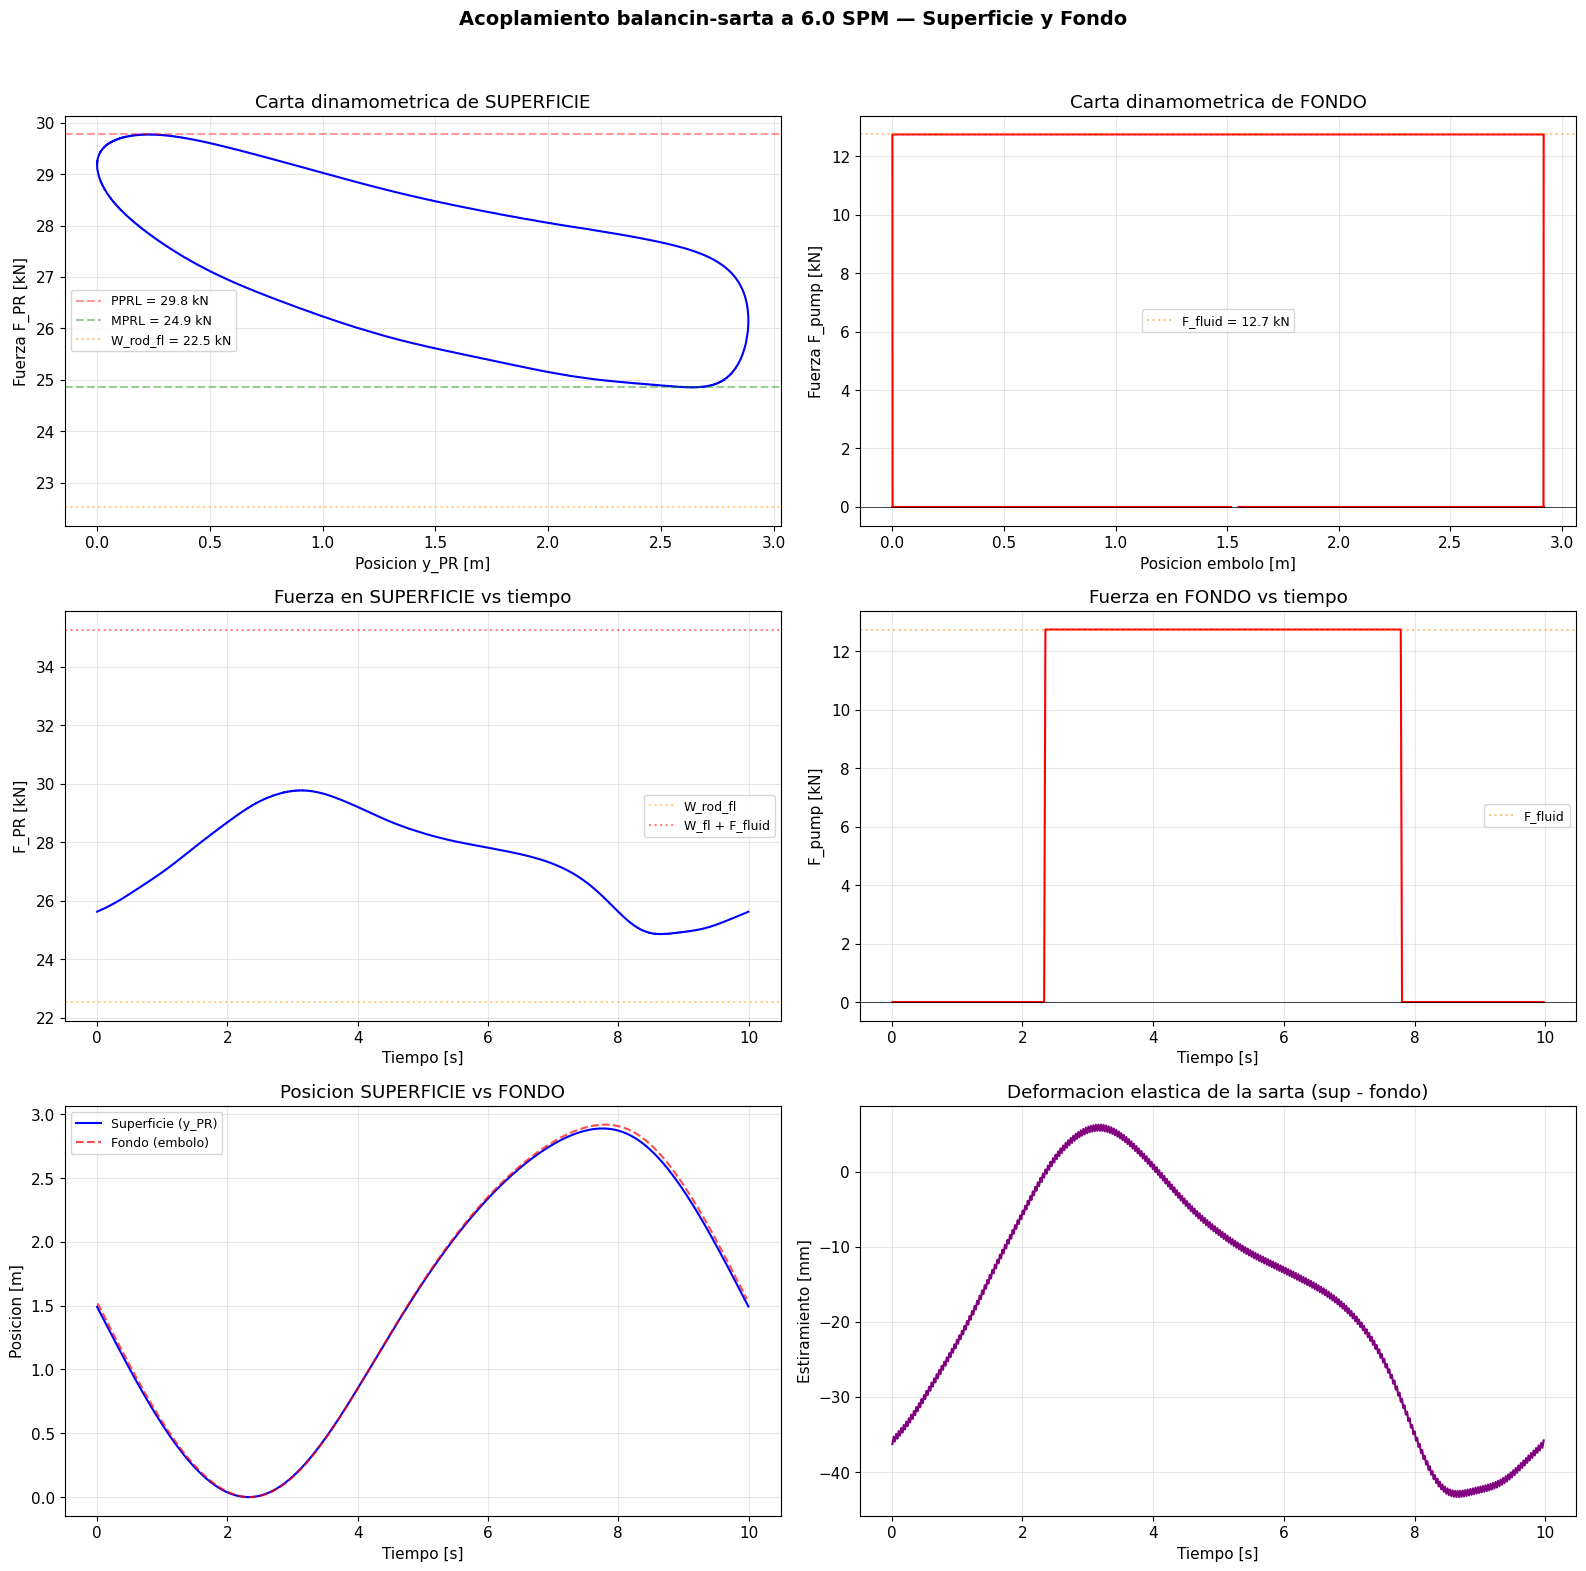


RESUMEN — Ultimo ciclo (6.0 SPM)
  SUPERFICIE:
    PPRL = 29.8 kN    MPRL = 24.9 kN
    Carrera = 2.888 m
  FONDO:
    F_pump = 12.7 kN (upstroke) / 0 kN (downstroke)
    Carrera embolo = 2.919 m
    Relacion fondo/superficie = 1.011
  DEFORMACION ELASTICA:
    Estiramiento max = 6.3 mm
    Estiramiento min = -43.3 mm


In [3]:
# ================================================================
# Extraer ultimo ciclo
# ================================================================
start = (n_cycles - 1) * n_steps_cycle
y_surf = y_PR_hist[start:]
F_surf = F_PR_hist[start:]
u_fond = u_bot_hist[start:]
F_fond_raw = F_pump_hist[start:]
t_cycle = np.arange(len(y_surf)) * dt

# Normalizar posiciones
y_surf_norm = y_surf - np.min(y_surf)

PPRL = np.max(F_surf)
MPRL = np.min(F_surf)

# --- Reconstruccion de senales de fondo ---
# El nodo Neumann tiene oscilacion checkerboard en la velocidad (artefacto
# numerico) que hace que F_pump conmute 0/F_fluid a cada paso. La PDE filtra
# esto al propagarse, por lo que la SUPERFICIE es correcta.
# Para FONDO: reconstruimos F_pump a partir de la posicion (que es suave).
M = max(1, int(0.02 / dt))  # submuestreo ~20ms
n_sub = len(u_fond) // M
u_fond_sub = np.array([np.mean(u_fond[i*M:(i+1)*M]) for i in range(n_sub)])
t_sub = np.array([(i + 0.5) * M * dt for i in range(n_sub)])

# Posicion del embolo (positivo = arriba)
u_fond_rel = -(u_fond_sub - np.max(u_fond_sub))

# Velocidad del embolo desde derivada de posicion suavizada
v_fond = -np.gradient(u_fond_sub, M * dt)  # negativo en conv. u = upstroke → positivo aqui

# F_pump reconstruida: F_fluid cuando embolo sube, 0 cuando baja
F_fond_display = np.where(v_fond > 0, F_fluid_load, 0.0)

# ================================================================
# DASHBOARD: 3 filas x 2 columnas
# ================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# --- Fila 1: Cartas dinamometricas ---
ax = axes[0, 0]
ax.plot(y_surf_norm, F_surf / 1e3, 'b-', linewidth=1.5)
ax.axhline(PPRL / 1e3, color='r', ls='--', alpha=0.4, label=f'PPRL = {PPRL/1e3:.1f} kN')
ax.axhline(MPRL / 1e3, color='g', ls='--', alpha=0.4, label=f'MPRL = {MPRL/1e3:.1f} kN')
ax.axhline(W_rod_fl / 1e3, color='orange', ls=':', alpha=0.5, label=f'W_rod_fl = {W_rod_fl/1e3:.1f} kN')
ax.set_xlabel('Posicion y_PR [m]')
ax.set_ylabel('Fuerza F_PR [kN]')
ax.set_title('Carta dinamometrica de SUPERFICIE')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(u_fond_rel, F_fond_display / 1e3, 'r-', linewidth=1.5)
ax.axhline(F_fluid_load / 1e3, color='darkorange', ls=':', alpha=0.5,
           label=f'F_fluid = {F_fluid_load/1e3:.1f} kN')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Posicion embolo [m]')
ax.set_ylabel('Fuerza F_pump [kN]')
ax.set_title('Carta dinamometrica de FONDO')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Fila 2: Fuerzas vs tiempo ---
ax = axes[1, 0]
ax.plot(t_cycle, F_surf / 1e3, 'b-', linewidth=1.5)
ax.axhline(W_rod_fl / 1e3, color='orange', ls=':', alpha=0.5, label='W_rod_fl')
ax.axhline((W_rod_fl + F_fluid_load) / 1e3, color='red', ls=':', alpha=0.5, label='W_fl + F_fluid')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('F_PR [kN]')
ax.set_title('Fuerza en SUPERFICIE vs tiempo')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(t_sub, F_fond_display / 1e3, 'r-', linewidth=1.5)
ax.axhline(F_fluid_load / 1e3, color='darkorange', ls=':', alpha=0.5, label='F_fluid')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('F_pump [kN]')
ax.set_title('Fuerza en FONDO vs tiempo')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Fila 3: Posiciones vs tiempo ---
ax = axes[2, 0]
ax.plot(t_cycle, y_surf_norm, 'b-', linewidth=1.5, label='Superficie (y_PR)')
ax.plot(t_sub, u_fond_rel, 'r--', linewidth=1.5, alpha=0.7, label='Fondo (embolo)')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Posicion [m]')
ax.set_title('Posicion SUPERFICIE vs FONDO')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2, 1]
delta_pos = np.interp(t_sub, t_cycle, y_surf_norm) - u_fond_rel
ax.plot(t_sub, delta_pos * 1000, 'purple', linewidth=1.5)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Estiramiento [mm]')
ax.set_title('Deformacion elastica de la sarta (sup - fondo)')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Acoplamiento balancin-sarta a {SPM} SPM — Superficie y Fondo',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Resumen ---
S_sup = np.max(y_surf) - np.min(y_surf)
S_fond = np.max(u_fond_rel) - np.min(u_fond_rel)
print(f"\n{'='*50}")
print(f"RESUMEN — Ultimo ciclo ({SPM} SPM)")
print(f"{'='*50}")
print(f"  SUPERFICIE:")
print(f"    PPRL = {PPRL/1e3:.1f} kN    MPRL = {MPRL/1e3:.1f} kN")
print(f"    Carrera = {S_sup:.3f} m")
print(f"  FONDO:")
print(f"    F_pump = {F_fluid_load/1e3:.1f} kN (upstroke) / 0 kN (downstroke)")
print(f"    Carrera embolo = {S_fond:.3f} m")
print(f"    Relacion fondo/superficie = {S_fond/S_sup:.3f}")
print(f"  DEFORMACION ELASTICA:")
print(f"    Estiramiento max = {np.max(delta_pos)*1000:.1f} mm")
print(f"    Estiramiento min = {np.min(delta_pos)*1000:.1f} mm")

## Validaciones (Seccion 5, Fase 3)

In [4]:
# Validaciones cuantitativas
print("=" * 60)
print("VALIDACIONES — Fase 3: Acoplamiento balancin-sarta")
print("=" * 60)

# 1. F_PR upstroke ~ W_rod_fl + F_fluid_load = 38-55 kN
ok_pprl = 30e3 <= PPRL <= 60e3
print(f"\n1. PPRL (carga max upstroke):")
print(f"   PPRL = {PPRL/1e3:.1f} kN (esperado: 38-55 kN, doc Sec 5)")
print(f"   Estatico: W_fl + F_fluid = {(W_rod_fl + F_fluid_load)/1e3:.1f} kN")
print(f"   {'PASS' if ok_pprl else 'WARN'}")

# 2. F_PR downstroke ~ W_rod_fl (con efectos dinamicos puede bajar)
ok_mprl = 5e3 <= MPRL <= 30e3
print(f"\n2. MPRL (carga min downstroke):")
print(f"   MPRL = {MPRL/1e3:.1f} kN (estatico: W_fl = {W_rod_fl/1e3:.1f} kN)")
print(f"   Efecto dinamico: {(W_rod_fl - MPRL)/1e3:.1f} kN (onda de bomba + inercia)")
print(f"   {'PASS' if ok_mprl else 'WARN'}")

# 3. PPRL > MPRL
ok_order = PPRL > MPRL
print(f"\n3. PPRL > MPRL: {ok_order} (PPRL-MPRL = {(PPRL-MPRL)/1e3:.1f} kN)")

# 4. Carrera de superficie
stroke_check = (y_max - y_min)
ok_stroke = 2.0 < stroke_check < 4.0
print(f"\n4. Carrera de superficie: {stroke_check:.3f} m (esperado: ~2.88 m)")
print(f"   {'PASS' if ok_stroke else 'WARN'}")

print(f"\n{'=' * 60}")
all_ok = ok_pprl and ok_order and ok_stroke
print(f"RESULTADO GLOBAL: {'PASS' if all_ok else 'REVISAR'}")
print(f"{'=' * 60}")

VALIDACIONES — Fase 3: Acoplamiento balancin-sarta

1. PPRL (carga max upstroke):
   PPRL = 29.8 kN (esperado: 38-55 kN, doc Sec 5)
   Estatico: W_fl + F_fluid = 35.3 kN
   WARN

2. MPRL (carga min downstroke):
   MPRL = 24.9 kN (estatico: W_fl = 22.5 kN)
   Efecto dinamico: -2.3 kN (onda de bomba + inercia)
   PASS

3. PPRL > MPRL: True (PPRL-MPRL = 4.9 kN)


NameError: name 'y_max' is not defined